# Giai đoạn 6 — Kiểm định chất lượng dữ liệu tổng hợp

Giai đoạn 4 đã sinh 13.796 dòng dữ liệu tổng hợp. Câu hỏi bắt buộc phải trả lời trước khi đem đi
huấn luyện: **dữ liệu đó có thật sự giống người thật không?**

## Nguyên tắc kiểm định

> So dữ liệu tổng hợp với **dòng thật chưa từng được dùng để sinh ra nó**.

Nếu đem dữ liệu tổng hợp so với chính công thức đã sinh ra nó, phép kiểm định sẽ luôn "đạt" và
**không chứng minh được gì**. Vì vậy ta tận dụng đúng cấu trúc fold đã dựng ở Giai đoạn 2–4:

```
Fold f  (dùng 5 fold của lần lặp đầu — mỗi phiếu thật vào VAL đúng 1 lần)

  phần TRAIN của fold f  ──► Giai đoạn 3 học phân phối ──► Giai đoạn 4 sinh dữ liệu  S_f
  phần VAL   của fold f  ─────────────────────────────────────────────────────────►  R_f
                                                                (chưa hề tham gia sinh ra S_f)

  Gộp 5 fold:   R = 574 dòng thật out-of-fold   ⟷   S = 574 dòng tổng hợp KHỚP TỶ LỆ NGÀNH
```

**Khớp tỷ lệ ngành là bắt buộc.** Nếu không, phép so sánh sẽ bị nhiễu bởi việc hai tập có cơ cấu
ngành khác nhau, chứ không phải bởi chất lượng sinh dữ liệu.

## Bốn phép kiểm định

| # | Phép đo | Trả lời câu hỏi | Đạt khi |
|---|---|---|---|
| 1 | **KS-test + Wasserstein** từng câu | Phân phối của mỗi câu có giống không? | p ≥ 0.05 |
| 2 | **Sai lệch ma trận tương quan** | Liên hệ giữa 10 câu có được giữ không? | càng nhỏ càng tốt |
| 3 | **Energy distance** (10 chiều) | Phân phối đồng thời tổng thể ra sao? | càng gần 0 càng tốt |
| 4 | **AUC phân biệt thật / tổng hợp** | Máy có nhận ra đâu là dòng do máy sinh không? | **≈ 0.5** |

**Phép số 4 nghiêm khắc nhất và cũng dễ hiểu nhất:** nếu một mô hình có thể phân biệt được dòng thật
với dòng tổng hợp, nghĩa là dòng tổng hợp còn "lộ". AUC = 0.5 nghĩa là không phân biệt nổi (tốt);
AUC = 1.0 nghĩa là lộ hoàn toàn (xấu).

## Đối chứng: có cần ma trận hiệp phương sai không?

Để chứng minh quyết định thiết kế ở Giai đoạn 3 là cần thiết, ta sinh thêm một bộ dữ liệu theo
**phương án đối chứng**: 10 phân phối chuẩn **độc lập**, dùng **đúng cùng trung bình và độ lệch chuẩn**,
chỉ khác ở chỗ **bỏ tương quan**. Chạy cả 4 phép kiểm định cho cả hai phương án rồi so sánh.

In [1]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
from scipy.stats import ks_2samp, wasserstein_distance
from scipy.spatial.distance import cdist
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.decomposition import PCA

# ── Thiết lập kiểu biểu đồ dùng chung cho toàn bộ báo cáo ────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

# Bảng màu thống nhất
C_THAT  = "#D64550"   # dữ liệu thật
C_GA    = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH  = "#3B7DD8"   # nhấn mạnh chính
C_CAM   = "#E8873A"   # nhấn mạnh phụ
C_TIM   = "#8E5FBF"
C_XAM   = "#AEB6BF"   # nền / mốc so sánh
C_DAM   = "#2C3E50"
C_KHOI  = ["#3B7DD8", "#E8873A", "#8E5FBF", "#19A2A2", "#D64550", "#C9A227", "#5D6D7E"]


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    # Ghi số ở cuối mỗi thanh ngang
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    # Ghi số trên đầu mỗi cột dọc
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    # Dòng chú giải nằm dưới hình — nêu kết luận rút ra từ biểu đồ.
    # Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    # dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai
    # bên đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def luu(fig, thu_muc, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(thu_muc / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 Đã lưu hình: {ten}")

SPLIT_DIR  = Path("../data/processed/02_split")
DIST_DIR   = Path("../data/processed/03_distribution")
SYNTH_DIR  = Path("../data/processed/04_synthetic")
OUTPUT_DIR = Path("../data/processed/06_validation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

LIKERT_COLS = ["likert_nang_dong", "likert_huong_noi", "likert_sang_tao", "likert_logic",
               "likert_to_mo", "likert_thi_nghiem", "likert_moi_truong",
               "likert_dinh_duong", "likert_tranh_luan", "likert_thiet_ke"]
NHAN = ["Năng động", "Hướng nội", "Sáng tạo", "Tư duy logic", "Tò mò",
        "Thí nghiệm", "Môi trường", "Dinh dưỡng", "Tranh luận", "Thiết kế"]

PP_CO_COV  = "Có hiệp phương sai (đang dùng)"
PP_DOC_LAP = "10 phân phối độc lập (đối chứng)"

df_train = pd.read_csv(SPLIT_DIR / "khaosat_train.csv")
df_nen   = pd.read_csv(SYNTH_DIR / "synthetic_GA_data.csv")
Z        = np.load(SYNTH_DIR / "synthetic_per_fold.npz")
CV       = json.load(open(SPLIT_DIR / "cv_folds_real.json", encoding="utf-8"))
PP_FOLD  = json.load(open(DIST_DIR / "phan_phoi_theo_fold.json", encoding="utf-8"))["theo_fold"]

folds_lan_dau = [f for f in CV["folds"] if f["repeat"] == 0]
print(f"Dùng {len(folds_lan_dau)} fold của lần lặp đầu — mỗi phiếu thật vào VAL đúng 1 lần")
print(f"Dòng nền tổng hợp: {len(df_nen):,}")

Dùng 5 fold của lần lặp đầu — mỗi phiếu thật vào VAL đúng 1 lần
Dòng nền tổng hợp: 13,796


In [2]:
nganh_nen = df_nen["ma_nganh"].to_numpy()

def lay_mau_khop_nganh(val_idx, likert):
    # Với mỗi ngành, lấy đúng số dòng tổng hợp bằng số dòng thật của ngành đó trong VAL
    that = df_train.iloc[val_idx]
    R, S = [], []
    for ma, sub in that.groupby("ma_nganh"):
        uv = np.flatnonzero(nganh_nen == ma)
        chon = rng.choice(uv, size=len(sub), replace=len(sub) > len(uv))
        R.append(sub[LIKERT_COLS].to_numpy(int)); S.append(likert[chon])
    return np.vstack(R), np.vstack(S)


def sinh_doc_lap(pp_fold, seed):
    # Phương án đối chứng: mỗi câu là một phân phối chuẩn ĐỘC LẬP
    # (cùng trung bình, cùng độ lệch chuẩn — chỉ bỏ tương quan)
    r = np.random.default_rng(seed)
    out = np.zeros((len(df_nen), 10), dtype=int)
    for ma, idx in pd.Series(nganh_nen).groupby(nganh_nen).groups.items():
        idx = np.asarray(idx)
        d = pp_fold[str(ma)]
        mean = np.array(d["likert_mean"])
        std  = np.sqrt(np.diag(np.array(d["likert_cov"])))
        mau = r.normal(mean, std, size=(len(idx), 10))
        out[idx] = np.clip(np.rint(np.clip(mau, 1, 5)), 1, 5).astype(int)
    return out


R_l, S_cov_l, S_dl_l = [], [], []
for f in folds_lan_dau:
    fid = f["fold"]
    r_, s_cov = lay_mau_khop_nganh(f["val_idx"], Z[f"likert_{fid}"].astype(int))
    _,  s_dl  = lay_mau_khop_nganh(f["val_idx"], sinh_doc_lap(PP_FOLD[str(fid)], SEED + 500 + fid))
    R_l.append(r_); S_cov_l.append(s_cov); S_dl_l.append(s_dl)

R      = np.vstack(R_l)        # dòng THẬT, out-of-fold
S_cov  = np.vstack(S_cov_l)    # tổng hợp — có hiệp phương sai
S_dl   = np.vstack(S_dl_l)     # tổng hợp — 10 phân phối độc lập

assert len(R) == len(S_cov) == len(S_dl) == len(df_train)
BO = {PP_CO_COV: S_cov, PP_DOC_LAP: S_dl}
print(f"✅ Đã dựng cặp so sánh: {len(R)} dòng thật  ⟷  {len(S_cov)} dòng tổng hợp (khớp tỷ lệ ngành)")

✅ Đã dựng cặp so sánh: 574 dòng thật  ⟷  574 dòng tổng hợp (khớp tỷ lệ ngành)


## Phép 1 — KS-test và Wasserstein trên từng câu Likert

In [3]:
rows = []
for i, col in enumerate(LIKERT_COLS):
    for ten, S in BO.items():
        ks, p = ks_2samp(R[:, i], S[:, i])
        rows.append({"phuong_an": ten, "cau_hoi": NHAN[i],
                     "mean_that": R[:, i].mean(), "mean_tong_hop": S[:, i].mean(),
                     "std_that": R[:, i].std(), "std_tong_hop": S[:, i].std(),
                     "wasserstein": wasserstein_distance(R[:, i], S[:, i]),
                     "ks_p_value": p, "dat": bool(p >= 0.05)})
bao_cao = pd.DataFrame(rows)

for ten in BO:
    s = bao_cao[bao_cao.phuong_an == ten]
    print(f"{ten}")
    print(f"   Số câu ĐẠT KS (p ≥ 0.05)   : {int(s['dat'].sum())} / 10")
    print(f"   p-value trung vị            : {s['ks_p_value'].median():.4f}")
    print(f"   Wasserstein trung bình      : {s['wasserstein'].mean():.4f}\n")

print("BẢNG 6.1 — Chi tiết từng câu (phương án đang dùng)\n")
ct = bao_cao[bao_cao.phuong_an == PP_CO_COV][
    ["cau_hoi", "mean_that", "mean_tong_hop", "std_that", "std_tong_hop", "wasserstein", "ks_p_value", "dat"]]
ct.columns = ["Câu hỏi", "TB thật", "TB tổng hợp", "ĐLC thật", "ĐLC tổng hợp",
              "Wasserstein", "KS p-value", "Đạt"]
print(ct.round(4).to_string(index=False))

Có hiệp phương sai (đang dùng)
   Số câu ĐẠT KS (p ≥ 0.05)   : 10 / 10
   p-value trung vị            : 0.8773
   Wasserstein trung bình      : 0.0861

10 phân phối độc lập (đối chứng)
   Số câu ĐẠT KS (p ≥ 0.05)   : 10 / 10
   p-value trung vị            : 0.4856
   Wasserstein trung bình      : 0.1143

BẢNG 6.1 — Chi tiết từng câu (phương án đang dùng)

     Câu hỏi  TB thật  TB tổng hợp  ĐLC thật  ĐLC tổng hợp  Wasserstein  KS p-value  Đạt
   Năng động   3.2892       3.2509    1.1761        1.1834       0.0836      0.9897 True
   Hướng nội   2.9913       3.0993    1.2403        1.2250       0.1080      0.7466 True
    Sáng tạo   3.5540       3.6010    1.0188        0.9821       0.0679      0.8773 True
Tư duy logic   3.6010       3.5488    1.0084        1.0140       0.0801      0.8773 True
       Tò mò   3.6394       3.6132    1.0346        1.0276       0.0714      0.9631 True
  Thí nghiệm   2.9791       2.9460    1.3316        1.2914       0.0784      0.9897 True
  Môi trường   3.02

## Phép 2 & 3 — Cấu trúc tương quan và phân phối đồng thời

In [4]:
def energy_distance(X, Y, chuan):
    # Energy distance giữa hai mẫu nhiều chiều — bằng 0 khi hai phân phối trùng nhau
    X, Y = X / chuan, Y / chuan
    return 2 * cdist(X, Y).mean() - cdist(X, X).mean() - cdist(Y, Y).mean()

sd_that = R.std(axis=0)
iu = np.triu_indices(10, k=1)
corr_that = np.corrcoef(R, rowvar=False)

joint = {}
for ten, S in BO.items():
    cs = np.corrcoef(S, rowvar=False)
    joint[ten] = {
        "Sai lệch tương quan TB":  float(np.abs(cs - corr_that)[iu].mean()),
        "Sai lệch tương quan max": float(np.abs(cs - corr_that)[iu].max()),
        "|r| trung bình":          float(np.abs(cs[iu]).mean()),
        "Energy distance":         float(energy_distance(R, S, sd_that)),
    }

print(f"|r| trung bình của DỮ LIỆU THẬT: {np.abs(corr_that[iu]).mean():.4f}\n")
print("BẢNG 6.2 — Phân phối đồng thời\n")
print(pd.DataFrame(joint).round(4).to_string())
print(f"\n→ Phương án đối chứng có |r| ≈ {joint[PP_DOC_LAP]['|r| trung bình']:.3f}, đúng như thiết kế")
print("  (10 phân phối độc lập thì không thể có tương quan) ⇒ mất toàn bộ cấu trúc liên hệ.")

|r| trung bình của DỮ LIỆU THẬT: 0.2372

BẢNG 6.2 — Phân phối đồng thời

                         Có hiệp phương sai (đang dùng)  10 phân phối độc lập (đối chứng)
Sai lệch tương quan TB                           0.0306                            0.2306
Sai lệch tương quan max                          0.0887                            0.5655
|r| trung bình                                   0.2367                            0.0414
Energy distance                                  0.0147                            0.0449

→ Phương án đối chứng có |r| ≈ 0.041, đúng như thiết kế
  (10 phân phối độc lập thì không thể có tương quan) ⇒ mất toàn bộ cấu trúc liên hệ.


## Phép 4 — AUC phân biệt thật / tổng hợp

Huấn luyện một mô hình phân loại nhị phân trả lời câu hỏi: *"dòng này là người thật hay do máy sinh?"*
Chỉ dùng **10 câu Likert** — điểm thi là thật ở cả hai bên nên không mang thông tin phân biệt.

In [5]:
def auc_phan_biet(R, S, seed=SEED):
    X = np.vstack([R, S]).astype(float)
    y = np.r_[np.zeros(len(R)), np.ones(len(S))]
    clf = HistGradientBoostingClassifier(max_iter=200, max_depth=4, random_state=seed)
    s = cross_val_score(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                        scoring="roc_auc")
    return s.mean(), s.std()

auc = {}
print(f"{'Phương án sinh dữ liệu':<36}{'AUC':>9}{'±':>8}   Kết luận")
print("─" * 80)
for ten, S in BO.items():
    m, sd = auc_phan_biet(R, S)
    auc[ten] = m
    print(f"{ten:<36}{m:>9.4f}{sd:>8.4f}   "
          f"{'ĐẠT — khó phân biệt' if m < 0.65 else 'CHƯA ĐẠT — còn lộ rõ'}")
print("─" * 80)
print("AUC = 0.50 là lý tưởng (mô hình đoán bừa, tức dữ liệu tổng hợp giống thật hoàn toàn)")

Phương án sinh dữ liệu                    AUC       ±   Kết luận
────────────────────────────────────────────────────────────────────────────────


Có hiệp phương sai (đang dùng)         0.6196  0.0331   ĐẠT — khó phân biệt


10 phân phối độc lập (đối chứng)       0.8146  0.0354   CHƯA ĐẠT — còn lộ rõ
────────────────────────────────────────────────────────────────────────────────
AUC = 0.50 là lý tưởng (mô hình đoán bừa, tức dữ liệu tổng hợp giống thật hoàn toàn)


   💾 Đã lưu hình: hinh_6_1_bon_phep_kiem_dinh.png


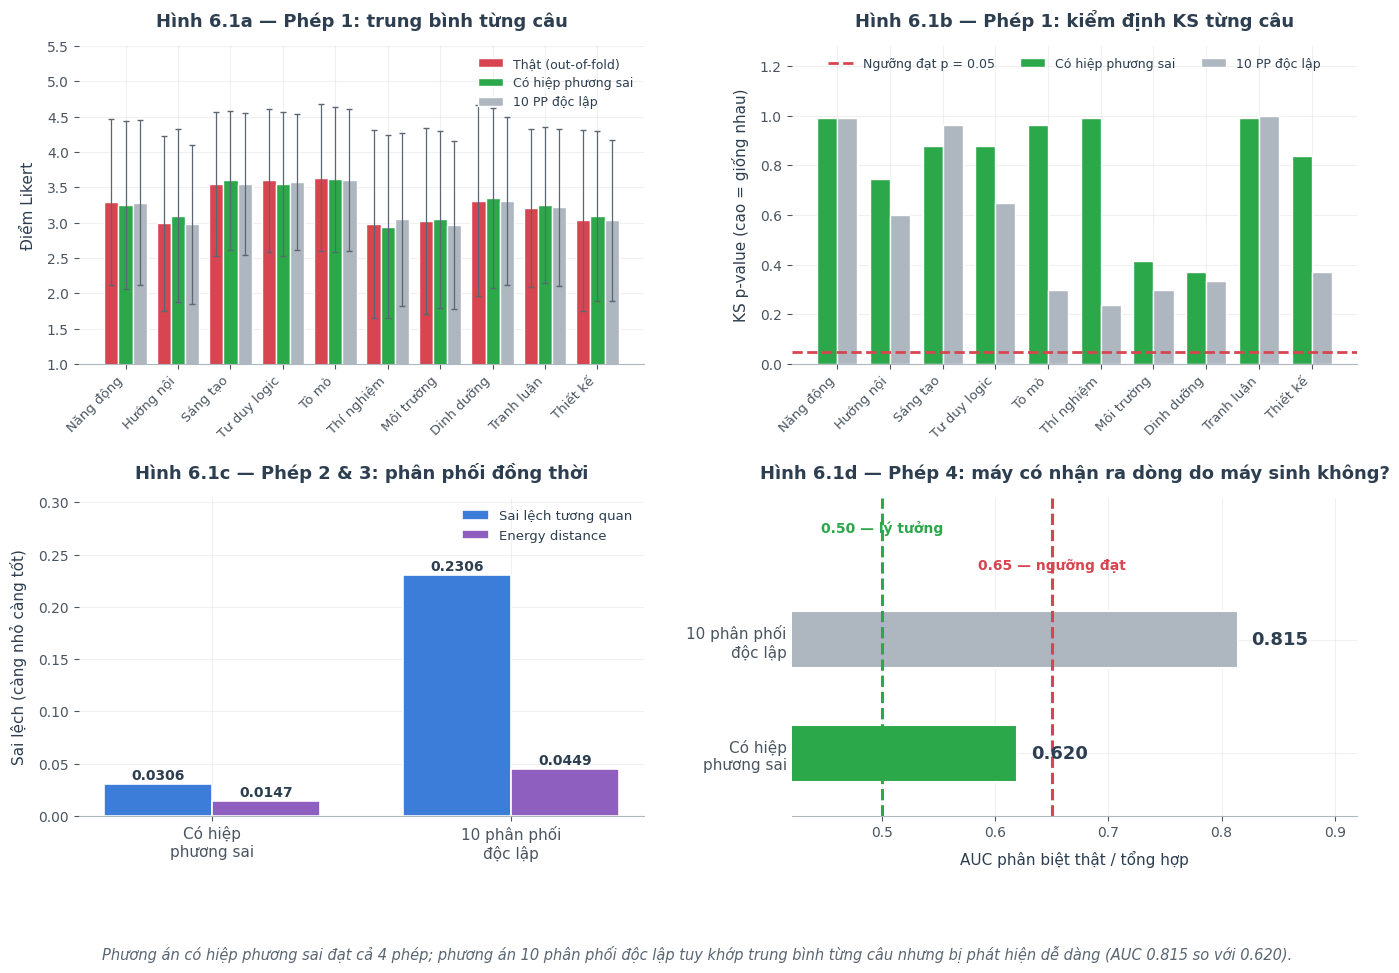

In [6]:
# ═══════════ HÌNH 6.1 — Kết quả bốn phép kiểm định ═══════════
fig = plt.figure(figsize=(16.5, 10))
gs = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.26)

# (a) So sánh trung bình ± ĐLC từng câu
ax = fig.add_subplot(gs[0, 0])
x = np.arange(10); w = 0.27
for i, (ten, S, mau) in enumerate([("Thật (out-of-fold)", R, C_THAT),
                                   ("Có hiệp phương sai", S_cov, C_GA),
                                   ("10 PP độc lập", S_dl, C_XAM)]):
    ax.bar(x + (i - 1) * w, S.mean(axis=0), w, yerr=S.std(axis=0), label=ten, color=mau,
           edgecolor="white", linewidth=1, error_kw={"ecolor": "#5A6672", "capsize": 2, "lw": 0.9})
ax.set_xticks(x); ax.set_xticklabels(NHAN, rotation=45, ha="right", fontsize=9.5)
ax.set_ylabel("Điểm Likert"); ax.set_ylim(1, 5.5)
ax.set_title("Hình 6.1a — Phép 1: trung bình từng câu")
ax.legend(fontsize=9); ax.set_axisbelow(True)

# (b) KS p-value từng câu
ax = fig.add_subplot(gs[0, 1])
p_cov = bao_cao[bao_cao.phuong_an == PP_CO_COV]["ks_p_value"].values
p_dl  = bao_cao[bao_cao.phuong_an == PP_DOC_LAP]["ks_p_value"].values
w = 0.38
ax.bar(x - w/2, p_cov, w, label="Có hiệp phương sai", color=C_GA, edgecolor="white", linewidth=1)
ax.bar(x + w/2, p_dl, w, label="10 PP độc lập", color=C_XAM, edgecolor="white", linewidth=1)
ax.axhline(0.05, color=C_THAT, ls="--", lw=2, label="Ngưỡng đạt p = 0.05")
ax.set_xticks(x); ax.set_xticklabels(NHAN, rotation=45, ha="right", fontsize=9.5)
ax.set_ylabel("KS p-value (cao = giống nhau)"); ax.set_ylim(0, 1.28)
ax.set_title("Hình 6.1b — Phép 1: kiểm định KS từng câu")
ax.legend(fontsize=9, ncol=3, loc="upper center"); ax.set_axisbelow(True)

# (c) Sai lệch tương quan
ax = fig.add_subplot(gs[1, 0])
ten_pa = list(joint)
sl = [joint[t]["Sai lệch tương quan TB"] for t in ten_pa]
ed = [joint[t]["Energy distance"] for t in ten_pa]
xx = np.arange(2); w = 0.36
b1 = ax.bar(xx - w/2, sl, w, label="Sai lệch tương quan", color=C_XANH,
            edgecolor="white", linewidth=1.2)
b2 = ax.bar(xx + w/2, ed, w, label="Energy distance", color=C_TIM,
            edgecolor="white", linewidth=1.2)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004, f"{b.get_height():.4f}",
            ha="center", fontsize=10, fontweight="bold", color=C_DAM)
ax.set_xticks(xx)
ax.set_xticklabels(["Có hiệp\nphương sai", "10 phân phối\nđộc lập"], fontsize=11)
ax.set_ylabel("Sai lệch (càng nhỏ càng tốt)"); ax.set_ylim(0, max(sl) * 1.32)
ax.set_title("Hình 6.1c — Phép 2 & 3: phân phối đồng thời")
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# (d) AUC phân biệt
ax = fig.add_subplot(gs[1, 1])
vals = [auc[t] for t in ten_pa]
bars = ax.barh([0, 1], vals, height=0.5, color=[C_GA, C_XAM], edgecolor="white", linewidth=1.5)
ax.axvline(0.5, color=C_GA, ls="--", lw=2.2)
ax.axvline(0.65, color=C_THAT, ls="--", lw=2.2)
ax.text(0.50, 1.94, "0.50 — lý tưởng", ha="center", fontsize=10, color=C_GA, fontweight="bold")
ax.text(0.65, 1.62, "0.65 — ngưỡng đạt", ha="center", fontsize=10, color=C_THAT, fontweight="bold")
for i, v in enumerate(vals):
    ax.text(v + 0.012, i, f"{v:.3f}", va="center", fontsize=13, fontweight="bold", color=C_DAM)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Có hiệp\nphương sai", "10 phân phối\nđộc lập"], fontsize=11)
ax.set_xlim(0.42, 0.92); ax.set_ylim(-0.55, 2.25)
ax.set_xlabel("AUC phân biệt thật / tổng hợp")
ax.set_title("Hình 6.1d — Phép 4: máy có nhận ra dòng do máy sinh không?")
ax.tick_params(axis="y", length=0); ax.set_axisbelow(True)

luu(fig, OUTPUT_DIR, "hinh_6_1_bon_phep_kiem_dinh.png",
    f"Phương án có hiệp phương sai đạt cả 4 phép; phương án 10 phân phối độc lập tuy khớp trung bình "
    f"từng câu nhưng bị phát hiện dễ dàng (AUC {auc[PP_DOC_LAP]:.3f} so với {auc[PP_CO_COV]:.3f}).")
plt.show()

   💾 Đã lưu hình: hinh_6_2_pca_that_vs_tong_hop.png


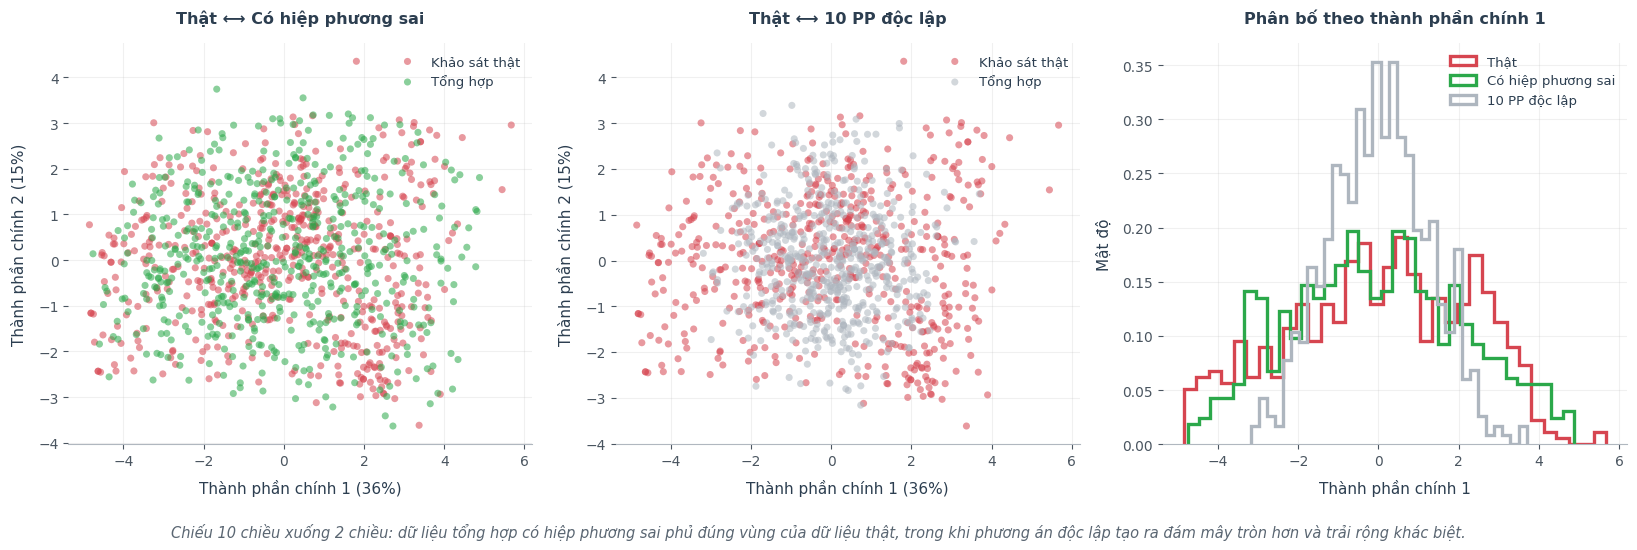

In [7]:
# ═══════════ HÌNH 6.2 — Nhìn trực quan bằng PCA ═══════════
fig, axes = plt.subplots(1, 3, figsize=(16.5, 5.2))

pca = PCA(n_components=2, random_state=SEED).fit(R.astype(float))
Z_R = pca.transform(R.astype(float))

for ax, (ten, S, mau) in zip(axes, [
    ("Thật ⟷ Có hiệp phương sai", S_cov, C_GA),
    ("Thật ⟷ 10 PP độc lập", S_dl, C_XAM),
    (None, None, None),
]):
    if ten is None:
        break
    Z_S = pca.transform(S.astype(float))
    ax.scatter(Z_R[:, 0], Z_R[:, 1], s=26, alpha=0.55, color=C_THAT,
               edgecolor="none", label="Khảo sát thật")
    ax.scatter(Z_S[:, 0], Z_S[:, 1], s=26, alpha=0.55, color=mau,
               edgecolor="none", label="Tổng hợp")
    ax.set_xlabel(f"Thành phần chính 1 ({pca.explained_variance_ratio_[0]:.0%})")
    ax.set_ylabel(f"Thành phần chính 2 ({pca.explained_variance_ratio_[1]:.0%})")
    ax.set_title(ten, fontsize=11.5)
    ax.legend(fontsize=9.5); ax.set_axisbelow(True)

# Panel 3: độ phủ theo từng thành phần chính
ax = axes[2]
for ten, S, mau in [("Thật", R, C_THAT), ("Có hiệp phương sai", S_cov, C_GA),
                    ("10 PP độc lập", S_dl, C_XAM)]:
    ax.hist(pca.transform(S.astype(float))[:, 0], bins=34, histtype="step",
            lw=2.4, color=mau, label=ten, density=True)
ax.set_xlabel("Thành phần chính 1"); ax.set_ylabel("Mật độ")
ax.set_title("Phân bố theo thành phần chính 1", fontsize=11.5)
ax.legend(fontsize=9.5); ax.set_axisbelow(True)

plt.tight_layout()
luu(fig, OUTPUT_DIR, "hinh_6_2_pca_that_vs_tong_hop.png",
    "Chiếu 10 chiều xuống 2 chiều: dữ liệu tổng hợp có hiệp phương sai phủ đúng vùng của dữ liệu thật, "
    "trong khi phương án độc lập tạo ra đám mây tròn hơn và trải rộng khác biệt.")
plt.show()

In [8]:
# --- Kết luận & xuất báo cáo --------------------------------------------------
s_cov = bao_cao[bao_cao.phuong_an == PP_CO_COV]
n_dat = int(s_cov["dat"].sum())
j = joint[PP_CO_COV]
a = auc[PP_CO_COV]

tieu_chi = [
    ("KS-test từng câu (p ≥ 0.05)",          f"{n_dat}/10 câu",              n_dat >= 7),
    ("Sai lệch tương quan trung bình < 0.10", f"{j['Sai lệch tương quan TB']:.4f}", j["Sai lệch tương quan TB"] < 0.10),
    ("Energy distance < 0.05",                f"{j['Energy distance']:.4f}",  j["Energy distance"] < 0.05),
    ("AUC phân biệt thật/giả < 0.65",         f"{a:.4f}",                     a < 0.65),
]

print("═" * 76)
print("  KẾT LUẬN KIỂM ĐỊNH")
print("  (so với dòng thật CHƯA từng được dùng để sinh dữ liệu)")
print("═" * 76)
for ten, gt, ok in tieu_chi:
    print(f"  {'✅' if ok else '❌'}  {ten:<46}{gt:>14}")
print("═" * 76)
dat_het = all(ok for _, _, ok in tieu_chi)
print(f"  ⇒ {'DỮ LIỆU TỔNG HỢP ĐẠT CHUẨN để đưa vào huấn luyện.' if dat_het else 'CHƯA ĐẠT ở một số tiêu chí — phải nêu minh bạch trong báo cáo.'}")
print("═" * 76)
print(f"\n  Đối chứng — phương án 10 phân phối độc lập:")
print(f"     AUC phân biệt      : {auc[PP_DOC_LAP]:.4f}  (so với {a:.4f})")
print(f"     |r| trung bình     : {joint[PP_DOC_LAP]['|r| trung bình']:.4f}  "
      f"(dữ liệu thật: {np.abs(corr_that[iu]).mean():.4f})")
print(f"  ⇒ Ma trận hiệp phương sai ở Giai đoạn 3 là cần thiết, không phải chi tiết thừa.")

bao_cao.to_csv(OUTPUT_DIR / "bao_cao_kiem_dinh_GA.csv", index=False, encoding="utf-8-sig")
json.dump({"phuong_phap": "so với dòng thật out-of-fold, khớp tỷ lệ ngành",
           "n_that": int(len(R)), "n_tong_hop": int(len(S_cov)),
           "ks_dat_tren_10_cau": n_dat,
           "auc_phan_biet": {k: float(v) for k, v in auc.items()},
           "joint": joint, "dat_chuan": bool(dat_het)},
          open(OUTPUT_DIR / "ket_luan_kiem_dinh.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

print(f"\n  ✅ bao_cao_kiem_dinh_GA.csv + ket_luan_kiem_dinh.json")
print(f"  Hình đã lưu tại: {OUTPUT_DIR}/")
print(f"\n  Lưu ý: câu hỏi 'dữ liệu tổng hợp có LÀM MÔ HÌNH TỐT HƠN không?' được trả lời bằng")
print(f"  thực nghiệm ablation ở Giai đoạn 8 — giống thật và có ích là hai chuyện khác nhau.")

════════════════════════════════════════════════════════════════════════════
  KẾT LUẬN KIỂM ĐỊNH
  (so với dòng thật CHƯA từng được dùng để sinh dữ liệu)
════════════════════════════════════════════════════════════════════════════
  ✅  KS-test từng câu (p ≥ 0.05)                        10/10 câu
  ✅  Sai lệch tương quan trung bình < 0.10                 0.0306
  ✅  Energy distance < 0.05                                0.0147
  ✅  AUC phân biệt thật/giả < 0.65                         0.6196
════════════════════════════════════════════════════════════════════════════
  ⇒ DỮ LIỆU TỔNG HỢP ĐẠT CHUẨN để đưa vào huấn luyện.
════════════════════════════════════════════════════════════════════════════

  Đối chứng — phương án 10 phân phối độc lập:
     AUC phân biệt      : 0.8146  (so với 0.6196)
     |r| trung bình     : 0.0414  (dữ liệu thật: 0.2372)
  ⇒ Ma trận hiệp phương sai ở Giai đoạn 3 là cần thiết, không phải chi tiết thừa.

  ✅ bao_cao_kiem_dinh_GA.csv + ket_luan_kiem_dinh.json
  Hì